---
## 📦 Cell 1 — Import Library

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from keras.utils import to_categorical
from keras.models import Model
from keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    Bidirectional, LSTM, Layer, GaussianNoise
)
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.regularizers import l2

PATH_CONFIGURATION_GENERAL = 'Epoch250'

print(f'TensorFlow  : {tf.__version__}')
print(f'Keras       : {tf.keras.__version__}')
print(f'GPU tersedia: {tf.config.list_physical_devices("GPU")}')

TensorFlow  : 2.17.0
Keras       : 3.4.1
GPU tersedia: []


---
## ⚙️ Cell 2 — Konfigurasi

In [2]:
DATA_PATH = '../../DatasetSibiKeypoints'
sequence_length = 45
FITUR_PER_FRAME = 258            # pose(132) + lh(63) + rh(63), TANPA wajah
MODEL_OUTPUT    = f'{PATH_CONFIGURATION_GENERAL}/model11class.keras'
TEMP_CHECKPOINT = f'{PATH_CONFIGURATION_GENERAL}/temp_checkpoint.keras'

actions = np.array(['Saya', 'Makan', 'Obat', 'Agar', 'Kuat', 'Buah', 'Sayur', 'Ibu', 'An', 'Sabar', 'Siap'])

# ── Struktur fitur (penting untuk augmentasi yang benar) ─────
# Pose : 33 landmarks × 4 (x, y, z, visibility) = 132
# LH   : 21 landmarks × 3 (x, y, z)             = 63
# RH   : 21 landmarks × 3 (x, y, z)             = 63
# Total                                          = 258
POSE_DIM   = 132   # index 0..131
LH_DIM     = 63    # index 132..194
RH_DIM     = 63    # index 195..257
POSE_END   = POSE_DIM
LH_END     = POSE_END + LH_DIM
RH_END     = LH_END + RH_DIM   # = 258

# Distribusi folder per variasi jarak (referensi)
# Folder 0-168   : jarak 70-80 cm normal
# Folder 169-193 : jarak 70-80 cm lambat
# Folder 194-218 : jarak 70-80 cm cepat
# Folder 219-258 : jarak 50-60 cm normal
# Folder 259-299 : jarak 90-100 cm normal

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Kelas yang sering tertukar (untuk augmentasi extra) ──────
# Obat ↔ Saya, Saya ↔ Sabar
CONFUSABLE_CLASSES = ['Saya', 'Obat', 'Sabar']

# ── CATATAN: class_weight DIHAPUS ────────────────────────────
# Sebelumnya double-weighting (focal alpha + class_weight) menyebabkan
# loss meledak/terlalu kecil di awal → val_accuracy fluktuatif → early stop dini.
# Cukup pakai focal alpha saja, lebih stabil.

print('Kelas yang dilatih :', actions)
print('Jumlah kelas        :', len(actions))
print('Sequence length     :', sequence_length)
print('Fitur per frame     :', FITUR_PER_FRAME)
print('  - Pose : 0..{}    (132 = 33 × 4)'.format(POSE_END - 1))
print('  - LH   : {}..{}  (63 = 21 × 3)'.format(POSE_END, LH_END - 1))
print('  - RH   : {}..{}  (63 = 21 × 3)'.format(LH_END, RH_END - 1))
print('Output model        :', MODEL_OUTPUT)
print('Kelas tertukar      :', CONFUSABLE_CLASSES, '(akan dapat augmentasi extra)')

os.makedirs(os.path.dirname(MODEL_OUTPUT), exist_ok=True)
os.makedirs(os.path.dirname(TEMP_CHECKPOINT), exist_ok=True)
print('✅ Folder output siap:', os.path.dirname(MODEL_OUTPUT))

Kelas yang dilatih : ['Saya' 'Makan' 'Obat' 'Agar' 'Kuat' 'Buah' 'Sayur' 'Ibu' 'An' 'Sabar'
 'Siap']
Jumlah kelas        : 11
Sequence length     : 45
Fitur per frame     : 258
  - Pose : 0..131    (132 = 33 × 4)
  - LH   : 132..194  (63 = 21 × 3)
  - RH   : 195..257  (63 = 21 × 3)
Output model        : Epoch250/model11class.keras
Kelas tertukar      : ['Saya', 'Obat', 'Sabar'] (akan dapat augmentasi extra)
✅ Folder output siap: Epoch250


---
## 📂 Cell 3 — Load Dataset & Verifikasi

In [3]:
label_map = {label: num for num, label in enumerate(actions)}
print('Label map:', label_map)

sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)

    if not os.path.exists(action_path):
        print(f'⚠️  Folder tidak ditemukan: {action_path}')
        continue

    sequence_folders = sorted(
        [f for f in os.listdir(action_path) if f.isdigit()],
        key=int
    )

    loaded, skipped = 0, 0
    for sequence in sequence_folders:
        window = []
        try:
            for frame_num in range(sequence_length):
                res = np.load(os.path.join(action_path, sequence, f'{frame_num}.npy'))
                if res.shape[0] != FITUR_PER_FRAME:
                    raise ValueError(f'Fitur {res.shape[0]} != {FITUR_PER_FRAME} — cek extract_keypoints!')
                window.append(res)
            sequences.append(np.array(window))
            labels.append(label_map[action])
            loaded += 1
        except Exception:
            skipped += 1

    print(f'  {action:12s}: {loaded} dimuat, {skipped} dilewati')

X     = np.array(sequences, dtype=np.float32)
y_int = np.array(labels)
y     = to_categorical(y_int, num_classes=len(actions))

print(f'\n✅ Shape X : {X.shape}')   # (N, 45, 258)
print(f'✅ Shape y : {y.shape}')      # (N, 11)
print('\nDistribusi kelas:')
for u, c in zip(*np.unique(y_int, return_counts=True)):
    print(f'  {actions[u]:12s}: {c} sequence')

Label map: {'Saya': 0, 'Makan': 1, 'Obat': 2, 'Agar': 3, 'Kuat': 4, 'Buah': 5, 'Sayur': 6, 'Ibu': 7, 'An': 8, 'Sabar': 9, 'Siap': 10}
  Saya        : 300 dimuat, 0 dilewati
  Makan       : 300 dimuat, 0 dilewati
  Obat        : 300 dimuat, 0 dilewati
  Agar        : 300 dimuat, 0 dilewati
  Kuat        : 300 dimuat, 0 dilewati
  Buah        : 300 dimuat, 0 dilewati
  Sayur       : 300 dimuat, 0 dilewati
  Ibu         : 300 dimuat, 0 dilewati
  An          : 300 dimuat, 0 dilewati
  Sabar       : 300 dimuat, 0 dilewati
  Siap        : 300 dimuat, 0 dilewati

✅ Shape X : (3300, 45, 258)
✅ Shape y : (3300, 11)

Distribusi kelas:
  Saya        : 300 sequence
  Makan       : 300 sequence
  Obat        : 300 sequence
  Agar        : 300 sequence
  Kuat        : 300 sequence
  Buah        : 300 sequence
  Sayur       : 300 sequence
  Ibu         : 300 sequence
  An          : 300 sequence
  Sabar       : 300 sequence
  Siap        : 300 sequence


---
## ✂️ Cell 4 — Split Dataset (DULU, sebelum augmentasi)

In [4]:
# ════════════════════════════════════════════════════════════
#  PERBAIKAN PENTING: SPLIT DILAKUKAN SEBELUM AUGMENTASI
#  Dulu split setelah augmentasi → versi noise/scale dari sequence
#  yang sama bisa masuk ke train DAN test → test accuracy palsu 100%
#  tapi di inference real-time tertukar.
# ════════════════════════════════════════════════════════════

# 70% train | 15% val | 15% test — stratified pada DATA ASLI
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X, y_int, test_size=0.30, random_state=SEED, stratify=y_int
)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw, test_size=0.50, random_state=SEED, stratify=y_temp_raw
)

print(f'Train (asli) : {X_train_raw.shape[0]} sequence')
print(f'Val   (asli) : {X_val_raw.shape[0]} sequence')
print(f'Test  (asli) : {X_test_raw.shape[0]} sequence')
print('\nDistribusi train asli:')
for u, c in zip(*np.unique(y_train_raw, return_counts=True)):
    print(f'  {actions[u]:12s}: {c}')

Train (asli) : 2310 sequence
Val   (asli) : 495 sequence
Test  (asli) : 495 sequence

Distribusi train asli:
  Saya        : 210
  Makan       : 210
  Obat        : 210
  Agar        : 210
  Kuat        : 210
  Buah        : 210
  Sayur       : 210
  Ibu         : 210
  An          : 210
  Sabar       : 210
  Siap        : 210


---
## 🔀 Cell 5 — Augmentasi Data (struktur-aware, hanya train)

Melakukan augmentasi (HANYA pada train set)...

✅ Train (setelah augmentasi) : 18060
✅ Val                          : 495 (TIDAK diaugmentasi)
✅ Test                         : 495 (TIDAK diaugmentasi)

Distribusi kelas TRAIN setelah augmentasi:
  Saya        : 2100 ⭐
  Makan       : 1470
  Obat        : 2100 ⭐
  Agar        : 1470
  Kuat        : 1470
  Buah        : 1470
  Sayur       : 1470
  Ibu         : 1470
  An          : 1470
  Sabar       : 2100 ⭐
  Siap        : 1470


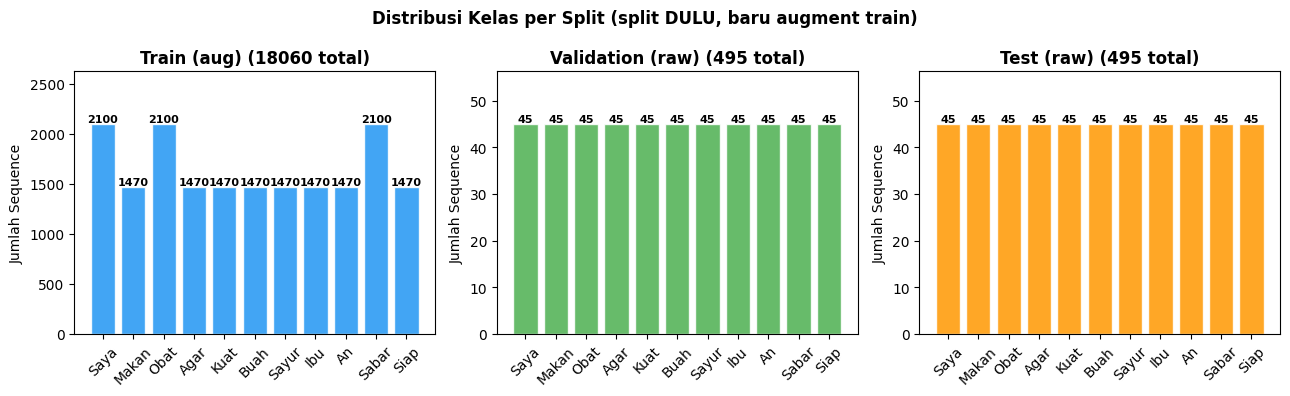

In [5]:
# ════════════════════════════════════════════════════════════
#  AUGMENTASI HANYA UNTUK TRAINING SET — STRUKTUR-AWARE
#  Augmentasi yang menyadari struktur pose/lh/rh, bukan asal kalikan
#  semua koordinat (yang merusak fitur visibility pose).
# ════════════════════════════════════════════════════════════

def split_features(seq):
    """Pisah seq (T, 258) → pose (T, 33, 4), lh (T, 21, 3), rh (T, 21, 3)."""
    pose = seq[:, :POSE_END].reshape(-1, 33, 4)
    lh   = seq[:, POSE_END:LH_END].reshape(-1, 21, 3)
    rh   = seq[:, LH_END:RH_END].reshape(-1, 21, 3)
    return pose, lh, rh


def merge_features(pose, lh, rh):
    """Gabungkan kembali ke seq (T, 258)."""
    T = pose.shape[0]
    return np.concatenate([
        pose.reshape(T, -1), lh.reshape(T, -1), rh.reshape(T, -1)
    ], axis=1).astype(np.float32)


def aug_gaussian_noise(seq, sigma=0.008):
    """Noise hanya pada x,y,z — visibility (kolom 4 pose) TIDAK di-noise."""
    pose, lh, rh = split_features(seq)
    pose_xyz = pose[:, :, :3] + np.random.normal(0, sigma, pose[:, :, :3].shape)
    pose_vis = pose[:, :, 3:4]   # visibility tetap
    pose_new = np.concatenate([pose_xyz, pose_vis], axis=-1)
    lh_new = lh + np.random.normal(0, sigma, lh.shape)
    rh_new = rh + np.random.normal(0, sigma, rh.shape)
    return merge_features(pose_new, lh_new, rh_new)


def aug_scale(seq, scale_range=(0.93, 1.07)):
    """Scaling x,y,z saja — visibility TIDAK di-scale."""
    s = np.random.uniform(*scale_range)
    pose, lh, rh = split_features(seq)
    pose_xyz = pose[:, :, :3] * s
    pose_vis = pose[:, :, 3:4]
    pose_new = np.concatenate([pose_xyz, pose_vis], axis=-1)
    return merge_features(pose_new, lh * s, rh * s)


def aug_time_warp(seq, factor_range=(0.85, 1.15)):
    """Time warping yang BENAR (versi sebelumnya buggy indexing)."""
    factor = np.random.uniform(*factor_range)
    T = seq.shape[0]
    new_T = max(2, int(T * factor))
    # Resample ke new_T frame, lalu re-resample kembali ke T frame
    old_x = np.linspace(0, 1, T)
    new_x = np.linspace(0, 1, new_T)
    # interp per dimensi fitur
    intermediate = np.array([
        np.interp(new_x, old_x, seq[:, fi]) for fi in range(seq.shape[1])
    ]).T  # (new_T, 258)
    # resample balik ke T
    final = np.array([
        np.interp(old_x, new_x, intermediate[:, fi]) for fi in range(seq.shape[1])
    ]).T  # (T, 258)
    return final.astype(np.float32)


def aug_frame_mask(seq, n_mask_range=(2, 6)):
    """Mask beberapa frame jadi 0 (simulasi occlusion)."""
    masked = seq.copy()
    n_mask = np.random.randint(*n_mask_range)
    mask_idx = np.random.choice(seq.shape[0], n_mask, replace=False)
    masked[mask_idx] = 0.0
    return masked


def aug_mirror_hands(seq):
    """
    Mirror horizontal: x → -x, dan SWAP tangan kiri ↔ kanan.
    PENTING untuk SIBI karena gerakan bisa pakai tangan kiri ATAU kanan.
    Kunci untuk membedakan Saya/Obat/Sabar yang trajectory-nya mirip.
    """
    pose, lh, rh = split_features(seq)

    # Flip x untuk pose
    pose_flipped = pose.copy()
    pose_flipped[:, :, 0] = -pose_flipped[:, :, 0]

    # Flip x untuk hand keypoints, lalu SWAP lh ↔ rh
    lh_flipped = lh.copy(); lh_flipped[:, :, 0] = -lh_flipped[:, :, 0]
    rh_flipped = rh.copy(); rh_flipped[:, :, 0] = -rh_flipped[:, :, 0]

    # SWAP: tangan kiri jadi kanan, sebaliknya
    return merge_features(pose_flipped, rh_flipped, lh_flipped)


def aug_translation(seq, shift_range=0.03):
    """Geser kecil di x,y (simulasi posisi badan signer berbeda)."""
    dx = np.random.uniform(-shift_range, shift_range)
    dy = np.random.uniform(-shift_range, shift_range)
    pose, lh, rh = split_features(seq)
    pose_xyz = pose[:, :, :3].copy()
    pose_xyz[:, :, 0] += dx; pose_xyz[:, :, 1] += dy
    pose_new = np.concatenate([pose_xyz, pose[:, :, 3:4]], axis=-1)
    lh_new = lh.copy(); lh_new[:, :, 0] += dx; lh_new[:, :, 1] += dy
    rh_new = rh.copy(); rh_new[:, :, 0] += dx; rh_new[:, :, 1] += dy
    return merge_features(pose_new, lh_new, rh_new)


def augment_sequence(seq, label_idx):
    """
    Hasilkan augmentasi per sequence.
    Untuk kelas yang sering tertukar (Saya, Obat, Sabar) → lebih banyak augmentasi.
    """
    augs = [
        aug_gaussian_noise(seq),
        aug_scale(seq),
        aug_time_warp(seq),
        aug_frame_mask(seq),
        aug_mirror_hands(seq),       # ← BARU, penting
        aug_translation(seq),         # ← BARU
    ]

    # Augmentasi extra untuk kelas yang sering tertukar
    label_name = actions[label_idx]
    if label_name in CONFUSABLE_CLASSES:
        # Kombinasi: noise + mirror, scale + warp, dst.
        augs.append(aug_gaussian_noise(aug_mirror_hands(seq)))
        augs.append(aug_scale(aug_time_warp(seq)))
        augs.append(aug_translation(aug_gaussian_noise(seq)))

    return augs


print('Melakukan augmentasi (HANYA pada train set)...')
X_train_aug_list = list(X_train_raw)
y_train_aug_list = list(y_train_raw)

for seq, lbl in zip(X_train_raw, y_train_raw):
    for aug_seq in augment_sequence(seq, lbl):
        X_train_aug_list.append(aug_seq)
        y_train_aug_list.append(lbl)

X_train = np.array(X_train_aug_list, dtype=np.float32)
y_train_int = np.array(y_train_aug_list)
y_train = to_categorical(y_train_int, num_classes=len(actions))

# Val & test TIDAK diaugmentasi (hanya konversi ke categorical)
X_val  = X_val_raw.astype(np.float32)
y_val  = to_categorical(y_val_raw, num_classes=len(actions))
X_test = X_test_raw.astype(np.float32)
y_test = to_categorical(y_test_raw, num_classes=len(actions))

print(f'\n✅ Train (setelah augmentasi) : {X_train.shape[0]}')
print(f'✅ Val                          : {X_val.shape[0]} (TIDAK diaugmentasi)')
print(f'✅ Test                         : {X_test.shape[0]} (TIDAK diaugmentasi)')

print('\nDistribusi kelas TRAIN setelah augmentasi:')
for u, c in zip(*np.unique(y_train_int, return_counts=True)):
    extra = ' ⭐' if actions[u] in CONFUSABLE_CLASSES else ''
    print(f'  {actions[u]:12s}: {c}{extra}')

# ── Plot distribusi split ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, y_s), color in zip(
    axes,
    {'Train (aug)': y_train, 'Validation (raw)': y_val, 'Test (raw)': y_test}.items(),
    ['#2196F3', '#4CAF50', '#FF9800']
):
    counts = np.sum(y_s, axis=0).astype(int)
    bars = ax.bar(actions, counts, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{name} ({y_s.shape[0]} total)', fontweight='bold')
    ax.set_ylabel('Jumlah Sequence')
    ax.set_ylim(0, max(counts) * 1.25)
    ax.tick_params(axis='x', rotation=45)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(counts)*0.01, str(c),
                ha='center', fontweight='bold', fontsize=8)

plt.suptitle('Distribusi Kelas per Split (split DULU, baru augment train)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PATH_CONFIGURATION_GENERAL}/plot_distribusi_split.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 🧠 Cell 6 — Arsitektur Model

In [6]:
class AttentionLayer(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        return tf.reduce_sum(x * a, axis=1)

    def get_config(self):
        return super().get_config()


# ── Focal loss dengan label smoothing (subclass agar bisa di-save/load) ──
@tf.keras.utils.register_keras_serializable(package='custom')
class FocalLossWithSmoothing(tf.keras.losses.Loss):
    """Focal loss + label smoothing. Bisa disimpan & di-load tanpa custom_objects.

    Label smoothing 0.05 mencegah model jadi overconfident → membantu
    membedakan Saya/Obat/Sabar yang trajectory-nya mirip.
    """
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.05,
                 name='focal_loss_with_smoothing', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha if alpha is not None else [1.0] * 11
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        n_classes = tf.shape(y_pred)[-1]
        # Label smoothing
        y_true_smooth = y_true * (1.0 - self.label_smoothing) + \
                        self.label_smoothing / tf.cast(n_classes, tf.float32)

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true_smooth * tf.math.log(y_pred)

        alpha_tensor = tf.constant(self.alpha, dtype=tf.float32)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        alpha_w = tf.reduce_sum(y_true * alpha_tensor, axis=-1, keepdims=True)
        focal_w = alpha_w * tf.pow(1.0 - pt, self.gamma)
        return tf.reduce_mean(focal_w * ce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'gamma': self.gamma,
            'alpha': self.alpha,
            'label_smoothing': self.label_smoothing,
        })
        return cfg


def build_model(seq_len, n_features, n_classes):
    inputs = Input(shape=(seq_len, n_features))

    # Input noise ringan → regularisasi tambahan
    x = GaussianNoise(0.005)(inputs)

    # BiLSTM
    x = Bidirectional(LSTM(96, return_sequences=True,
                           kernel_regularizer=l2(0.001),
                           recurrent_dropout=0.0))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Bidirectional(LSTM(64, return_sequences=True,
                           kernel_regularizer=l2(0.001),
                           recurrent_dropout=0.0))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = AttentionLayer()(x)

    # Dense
    x = Dense(192, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(96, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)

    x = Dense(48, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.2)(x)

    outputs = Dense(n_classes, activation='softmax')(x)
    return Model(inputs, outputs, name='BiLSTM_Attention_SIBI_11class_v2')


# ── Focal alpha: distribusikan dengan kelas tertukar lebih tinggi ───
# Kelas tertukar (Saya, Obat, Sabar) dapat alpha lebih tinggi
# tapi TIDAK terlalu ekstrem (cegah training tidak stabil)
# Saya=0, Makan=1, Obat=2, Agar=3, Kuat=4, Buah=5,
# Sayur=6, Ibu=7, An=8, Sabar=9, Siap=10
FOCAL_ALPHA = [
    0.35,  # Saya  ← tertukar dengan Sabar
    0.25,  # Makan
    0.40,  # Obat  ← tertukar dengan Saya (paling tinggi)
    0.25,  # Agar
    0.25,  # Kuat
    0.25,  # Buah
    0.25,  # Sayur
    0.25,  # Ibu
    0.25,  # An
    0.35,  # Sabar ← tertukar dengan Saya
    0.25,  # Siap
]

model = build_model(sequence_length, FITUR_PER_FRAME, len(actions))

# ── Optimizer: Adam dengan LR fixed, dikontrol via ReduceLROnPlateau ──
# CosineDecayRestarts sebelumnya menyebabkan LR jadi sangat kecil di restart
# kedua → model "stuck" sebelum convergence sebenarnya.
# Dengan ReduceLROnPlateau, LR turun HANYA saat val_loss plateau → lebih predictable.
model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss=FocalLossWithSmoothing(gamma=2.0, alpha=FOCAL_ALPHA, label_smoothing=0.05),
    metrics=['accuracy']
)
model.summary()

with open(f'{PATH_CONFIGURATION_GENERAL}/model_summary.txt', 'w', encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
print("✅ Model summary tersimpan : model_summary.txt")

Model: "BiLSTM_Attention_SIBI_11class_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 45, 258)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 45, 258)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 45, 192)        │       272,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 45, 192)        │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 45, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │           173 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 192)            │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,936 (1.74 MB)

 Trainable params: 453,912 (1.73 MB)

 Non-trainable params: 1,024 (4.00 KB)

✅ Model summary tersimpan : model_summary.txt


---
## 🏋️ Cell 7 — Training

In [7]:
import tensorflow as tf

# ════════════════════════════════════════════════════════════
#  CALLBACK YANG DIPERBAIKI
#  Masalah dulu: EarlyStopping pada val_accuracy yang fluktuatif
#                + restore_best_weights + patience 50 → training bisa
#                  berhenti < 100 epoch karena val_acc puncak di awal.
#
#  Sekarang: monitor val_loss (lebih halus), patience lebih besar,
#            min_delta untuk mengabaikan improvement sepele,
#            ReduceLROnPlateau untuk fine-tune saat plateau.
# ════════════════════════════════════════════════════════════

checkpoint = ModelCheckpoint(
    TEMP_CHECKPOINT,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=60,                  # ← lebih sabar dari sebelumnya
    min_delta=1e-4,               # ← abaikan improvement sangat kecil
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,                  # tunggu 15 epoch sebelum kurangi LR
    min_lr=1e-6,
    mode='min',
    verbose=1
)


class PerClassAccuracyCallback(tf.keras.callbacks.Callback):
    """Print per-class val accuracy setiap N epoch + tracking khusus untuk
    kelas yang sering tertukar."""
    def __init__(self, X_val, y_val, actions, every_n=10):
        self.X_val   = X_val
        self.y_val   = y_val
        self.actions = actions
        self.every_n = every_n
        self.best_per_class = {a: 0.0 for a in actions}

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n != 0:
            return
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        y_true = np.argmax(self.y_val, axis=1)
        print(f'\n  [Epoch {epoch+1}] Per-class val accuracy:')
        for i, action in enumerate(self.actions):
            mask = (y_true == i)
            if mask.sum() == 0:
                continue
            acc_i = (y_pred[mask] == i).mean()
            if acc_i > self.best_per_class[action]:
                self.best_per_class[action] = acc_i
            flag = ' ⚠️ ' if acc_i < 0.85 else ''
            star = ' ⭐' if action in CONFUSABLE_CLASSES else ''
            print(f'    {action:12s}: {acc_i*100:5.1f}% (best {self.best_per_class[action]*100:5.1f}%){flag}{star}')

        # Cek confusion antar kelas yang bermasalah
        idx_saya  = np.where(actions == 'Saya')[0][0]
        idx_obat  = np.where(actions == 'Obat')[0][0]
        idx_sabar = np.where(actions == 'Sabar')[0][0]
        # Obat → Saya
        mask_obat = (y_true == idx_obat)
        if mask_obat.sum() > 0:
            confused_obat_saya = ((y_pred[mask_obat] == idx_saya).sum() /
                                   mask_obat.sum() * 100)
            print(f'    [Confusion] Obat → Saya  : {confused_obat_saya:.1f}%')
        # Saya → Sabar
        mask_saya = (y_true == idx_saya)
        if mask_saya.sum() > 0:
            confused_saya_sabar = ((y_pred[mask_saya] == idx_sabar).sum() /
                                    mask_saya.sum() * 100)
            print(f'    [Confusion] Saya → Sabar : {confused_saya_sabar:.1f}%')


per_class_cb = PerClassAccuracyCallback(X_val, y_val, actions, every_n=10)

print('Memulai training...\n')
print('Catatan: training TIDAK pakai class_weight lagi → cegah double weighting')
print('         dengan focal alpha. Loss yang dipakai sudah handle imbalance.\n')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=250,                     # ← 250 epoch, sekarang BISA jalan sampai habis
    batch_size=64,
    callbacks=[early_stop, checkpoint, reduce_lr, per_class_cb],
    # class_weight=...   # ← DIHAPUS, lihat catatan di atas
    verbose=1,
    shuffle=True,
)

# Load best model — focal loss sudah registered, tidak perlu custom_objects
best_model = tf.keras.models.load_model(
    TEMP_CHECKPOINT,
    custom_objects={'AttentionLayer': AttentionLayer,
                    'FocalLossWithSmoothing': FocalLossWithSmoothing}
)

best_model.save(MODEL_OUTPUT)

if os.path.exists(TEMP_CHECKPOINT):
    os.remove(TEMP_CHECKPOINT)

print(f'\n✅ Model terbaik disimpan : {MODEL_OUTPUT}')
print(f'   Total epoch berjalan   : {len(history.history["loss"])}')
print(f'   Val loss terbaik       : {min(history.history["val_loss"]):.4f}')
print(f'   Val accuracy terbaik   : {max(history.history["val_accuracy"])*100:.2f}%')
print(f'   Epoch terbaik (val_loss) : {np.argmin(history.history["val_loss"]) + 1}')

Memulai training...

Catatan: training TIDAK pakai class_weight lagi → cegah double weighting
         dengan focal alpha. Loss yang dipakai sudah handle imbalance.

Epoch 1/250
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5576 - loss: 0.9098
Epoch 1: val_loss improved from inf to 0.16807, saving model to Epoch250/temp_checkpoint.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.5588 - loss: 0.9073 - val_accuracy: 0.7576 - val_loss: 0.1681 - learning_rate: 5.0000e-04
Epoch 2/250
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9290 - loss: 0.1007
Epoch 2: val_loss improved from 0.16807 to 0.03737, saving model to Epoch250/temp_checkpoint.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.9291 - loss: 0.1005 - val_accuracy: 0.9152 - val_loss: 0.0374 - learning_rate: 5.0000e-04
Epoch 3/250
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9581 - loss: 0.0248
Epoch 3: val_loss improved from 0.03737 to 0.01264, saving model to Epoch250/temp_

---
## 📈 Cell 8 — Plot Kurva Training

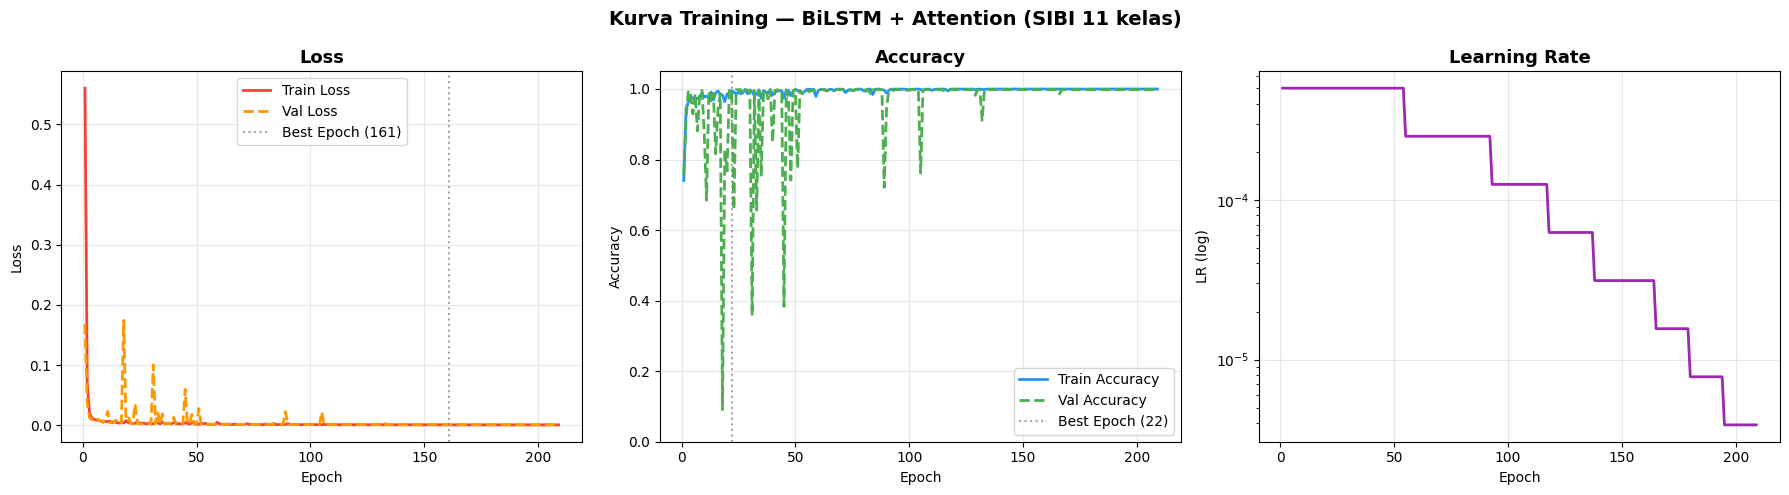

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

ax = axes[0]
ax.plot(epochs_range, history.history['loss'],
        color='#F44336', linewidth=2, label='Train Loss')
ax.plot(epochs_range, history.history['val_loss'],
        color='#FF9800', linewidth=2, linestyle='--', label='Val Loss')
best_ep = np.argmin(history.history['val_loss']) + 1
ax.axvline(x=best_ep, color='gray', linestyle=':', alpha=0.7,
           label=f'Best Epoch ({best_ep})')
ax.set_title('Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs_range, history.history['accuracy'],
        color='#2196F3', linewidth=2, label='Train Accuracy')
ax.plot(epochs_range, history.history['val_accuracy'],
        color='#4CAF50', linewidth=2, linestyle='--', label='Val Accuracy')
best_ep_acc = np.argmax(history.history['val_accuracy']) + 1
ax.axvline(x=best_ep_acc, color='gray', linestyle=':', alpha=0.7,
           label=f'Best Epoch ({best_ep_acc})')
ax.set_title('Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
if 'learning_rate' in history.history:
    ax.plot(epochs_range, history.history['learning_rate'],
            color='#9C27B0', linewidth=2)
    ax.set_yscale('log')
    ax.set_title('Learning Rate', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('LR (log)')
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'LR history\ntidak tersedia',
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Learning Rate', fontsize=13, fontweight='bold')

plt.suptitle('Kurva Training — BiLSTM + Attention (SIBI 11 kelas)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PATH_CONFIGURATION_GENERAL}/plot_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧪 Cell 9 — Evaluasi pada Test Set

In [9]:
loss, acc = best_model.evaluate(X_test, y_test, verbose=0)
print('=' * 50)
print(f'  TEST ACCURACY : {acc * 100:.2f}%')
print(f'  TEST LOSS     : {loss:.4f}')
print('=' * 50)

y_pred_prob = best_model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test,      axis=1)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=actions))

# Simpan classification report ke file teks
report_str = classification_report(y_true, y_pred, target_names=actions)
with open(f'{PATH_CONFIGURATION_GENERAL}/classification_report.txt', 'w') as f:
    f.write(f"Test Accuracy : {acc*100:.2f}%\n")
    f.write(f"Test Loss     : {loss:.4f}\n\n")
    f.write(report_str)
print("✅ Classification report tersimpan")

  TEST ACCURACY : 100.00%
  TEST LOSS     : 0.0004

Classification Report:
              precision    recall  f1-score   support

        Saya       1.00      1.00      1.00        45
       Makan       1.00      1.00      1.00        45
        Obat       1.00      1.00      1.00        45
        Agar       1.00      1.00      1.00        45
        Kuat       1.00      1.00      1.00        45
        Buah       1.00      1.00      1.00        45
       Sayur       1.00      1.00      1.00        45
         Ibu       1.00      1.00      1.00        45
          An       1.00      1.00      1.00        45
       Sabar       1.00      1.00      1.00        45
        Siap       1.00      1.00      1.00        45

    accuracy                           1.00       495
   macro avg       1.00      1.00      1.00       495
weighted avg       1.00      1.00      1.00       495

✅ Classification report tersimpan


---
## 🟦 Cell 10 — Confusion Matrix

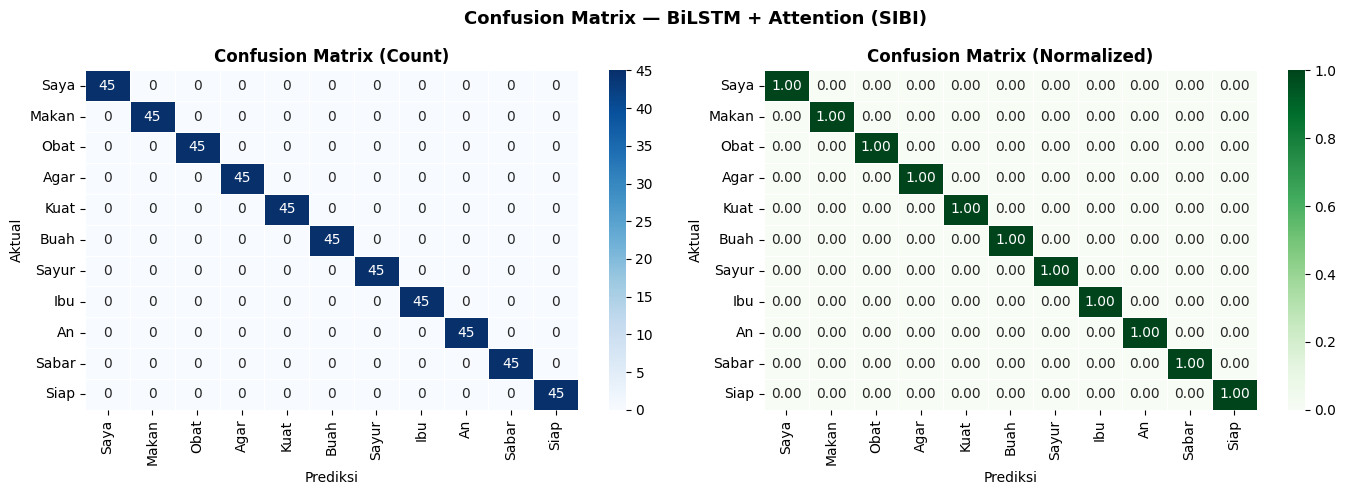


⚠️  Confusable Pairs:

🎯 Status pair bermasalah (target awal):
  Obat  → Saya  : 0 kali (target: 0)
  Saya  → Obat  : 0 kali (target: 0)
  Saya  → Sabar : 0 kali (target: 0)
  Sabar → Saya  : 0 kali (target: 0)


In [10]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=actions, yticklabels=actions, ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix (Count)', fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=actions, yticklabels=actions, ax=axes[1],
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — BiLSTM + Attention (SIBI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PATH_CONFIGURATION_GENERAL}/plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n⚠️  Confusable Pairs:')
for i in range(len(actions)):
    for j in range(len(actions)):
        if i != j and cm[i][j] > 0:
            print(f'  {actions[i]} → diprediksi {actions[j]}: {cm[i][j]} kali')

# Highlight pair yang jadi problem awal
print('\n🎯 Status pair bermasalah (target awal):')
idx_s = np.where(actions == 'Saya')[0][0]
idx_o = np.where(actions == 'Obat')[0][0]
idx_b = np.where(actions == 'Sabar')[0][0]
print(f'  Obat  → Saya  : {cm[idx_o][idx_s]} kali (target: 0)')
print(f'  Saya  → Obat  : {cm[idx_s][idx_o]} kali (target: 0)')
print(f'  Saya  → Sabar : {cm[idx_s][idx_b]} kali (target: 0)')
print(f'  Sabar → Saya  : {cm[idx_b][idx_s]} kali (target: 0)')

---
## 📊 Cell 11 — Per-Class Metrics

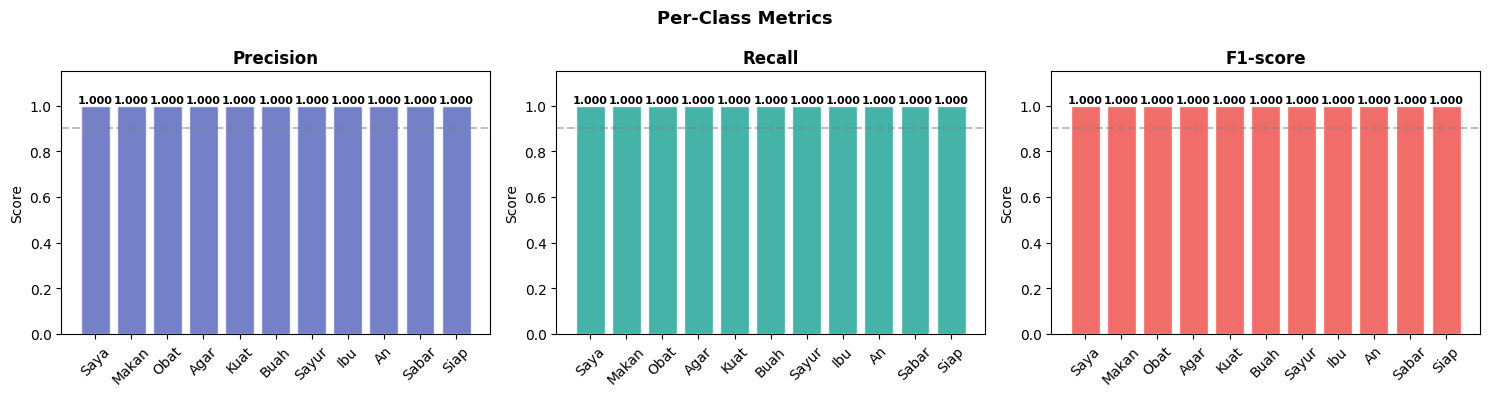

       precision  recall  f1-score  support
Saya         1.0     1.0       1.0     45.0
Makan        1.0     1.0       1.0     45.0
Obat         1.0     1.0       1.0     45.0
Agar         1.0     1.0       1.0     45.0
Kuat         1.0     1.0       1.0     45.0
Buah         1.0     1.0       1.0     45.0
Sayur        1.0     1.0       1.0     45.0
Ibu          1.0     1.0       1.0     45.0
An           1.0     1.0       1.0     45.0
Sabar        1.0     1.0       1.0     45.0
Siap         1.0     1.0       1.0     45.0


In [11]:
report    = classification_report(y_true, y_pred,
                                   target_names=actions, output_dict=True)
df_report = pd.DataFrame(report).transpose().loc[actions]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, color in zip(
    axes,
    ['precision', 'recall', 'f1-score'],
    ['#5C6BC0',   '#26A69A', '#EF5350']
):
    vals = df_report[metric].values
    bars = ax.bar(actions, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric.capitalize(), fontweight='bold')
    ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
    ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontweight='bold', fontsize=8)

plt.suptitle('Per-Class Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PATH_CONFIGURATION_GENERAL}/plot_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_report[['precision','recall','f1-score','support']].to_string())

---
## 🎯 Cell 12 — Analisis Confidence

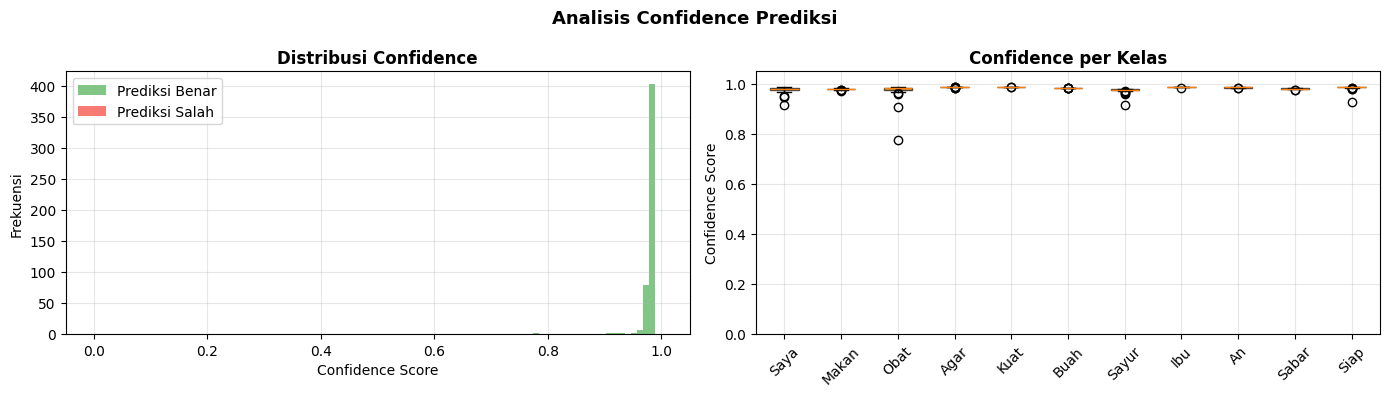

Confidence rata-rata benar : 0.9817
Confidence rata-rata salah : nan


In [12]:
max_conf   = np.max(y_pred_prob, axis=1)
is_correct = (y_pred == y_true)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(max_conf[is_correct],  bins=20, alpha=0.7,
        color='#4CAF50', label='Prediksi Benar')
ax.hist(max_conf[~is_correct], bins=20, alpha=0.7,
        color='#F44336', label='Prediksi Salah')
ax.set_title('Distribusi Confidence', fontweight='bold')
ax.set_xlabel('Confidence Score'); ax.set_ylabel('Frekuensi')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
bp = ax.boxplot(
    [max_conf[y_true == i] for i in range(len(actions))],
    labels=actions, patch_artist=True
)
colors_cycle = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336',
                '#00BCD4','#FFC107','#795548','#E91E63','#607D8B','#8BC34A']
for patch, c in zip(bp['boxes'], colors_cycle):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_title('Confidence per Kelas', fontweight='bold')
ax.set_ylabel('Confidence Score'); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Analisis Confidence Prediksi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PATH_CONFIGURATION_GENERAL}/plot_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Confidence rata-rata benar : {max_conf[is_correct].mean():.4f}')
print(f'Confidence rata-rata salah : {max_conf[~is_correct].mean():.4f}')

---
## 📋 Cell 13 — Ringkasan Akhir

In [13]:
report_full = classification_report(
    y_true, y_pred, target_names=actions, output_dict=True
)

print('=' * 60)
print('        RINGKASAN HASIL TRAINING — SIBI 11 KELAS (v2)')
print('=' * 60)
print(f'  Arsitektur    : BiLSTM + Attention + Focal Loss + Label Smoothing')
print(f'  Kelas         : {", ".join(actions)}')
print(f'  Total data    : {X.shape[0]} (asli) → train diaugmentasi')
print(f'  Fitur/frame   : {FITUR_PER_FRAME}')
print(f'  Sequence len  : {sequence_length} frame @ 30fps = {sequence_length/30:.1f} detik')
print('-' * 60)
print(f'  Train (aug) / Val / Test : {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]}')
print('-' * 60)
print(f'  Test Accuracy : {acc * 100:.2f}%')
print(f'  Test Loss     : {loss:.4f}')
print(f'  Macro F1      : {report_full["macro avg"]["f1-score"]:.4f}')
print(f'  Weighted F1   : {report_full["weighted avg"]["f1-score"]:.4f}')
print('-' * 60)
print('  Per-Class:')
for action in actions:
    r = report_full[action]
    star = ' ⭐' if action in CONFUSABLE_CLASSES else ''
    print(f'  {action:12s}  P={r["precision"]:.3f}  '
          f'R={r["recall"]:.3f}  F1={r["f1-score"]:.3f}{star}')
print('=' * 60)
print(f'\n✅ Output model  : {MODEL_OUTPUT}')

# ── Simpan Ringkasan Training ke File ───────────────────────
with open(f'{PATH_CONFIGURATION_GENERAL}/ringkasan_training.txt', 'w', encoding='utf-8') as f:
    f.write('=' * 60 + '\n')
    f.write('        RINGKASAN HASIL TRAINING — SIBI 11 KELAS (v2)\n')
    f.write('=' * 60 + '\n')
    f.write(f'  Arsitektur    : BiLSTM + Attention + Focal Loss + Label Smoothing\n')
    f.write(f'  Kelas         : {", ".join(actions)}\n')
    f.write(f'  Jumlah Kelas  : {len(actions)}\n')
    f.write(f'  Total data    : {X.shape[0]} (asli) → train diaugmentasi\n')
    f.write(f'  Fitur/frame   : {FITUR_PER_FRAME}\n')
    f.write(f'  Sequence len  : {sequence_length} frame @ 30fps = {sequence_length/30:.1f} detik\n')
    f.write('-' * 60 + '\n')
    f.write(f'  Train (aug) / Val / Test : {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]}\n')
    f.write('-' * 60 + '\n')
    f.write(f'  Test Accuracy : {acc * 100:.2f}%\n')
    f.write(f'  Test Loss     : {loss:.4f}\n')
    f.write(f'  Macro F1      : {report_full["macro avg"]["f1-score"]:.4f}\n')
    f.write(f'  Weighted F1   : {report_full["weighted avg"]["f1-score"]:.4f}\n')
    f.write(f'  Macro P       : {report_full["macro avg"]["precision"]:.4f}\n')
    f.write(f'  Macro R       : {report_full["macro avg"]["recall"]:.4f}\n')
    f.write('-' * 60 + '\n')
    f.write(f'  Epoch terbaik (val_accuracy) : {np.argmax(history.history["val_accuracy"]) + 1}\n')
    f.write(f'  Epoch terbaik (val_loss)     : {np.argmin(history.history["val_loss"]) + 1}\n')
    f.write(f'  Total epoch berjalan         : {len(history.history["loss"])}\n')
    f.write(f'  Val Accuracy terbaik         : {max(history.history["val_accuracy"]) * 100:.2f}%\n')
    f.write(f'  Val Loss terbaik             : {min(history.history["val_loss"]):.4f}\n')
    f.write('-' * 60 + '\n')
    f.write('  Per-Class Metrics:\n')
    f.write(f'  {"Kelas":<14} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"Support":>10}\n')
    f.write('  ' + '-' * 50 + '\n')
    for action in actions:
        r = report_full[action]
        f.write(f'  {action:<14} {r["precision"]:>10.4f} {r["recall"]:>10.4f} '
                f'{r["f1-score"]:>10.4f} {int(r["support"]):>10}\n')
    f.write('-' * 60 + '\n')
    f.write('  Kelas tertukar (target perbaikan):\n')
    f.write(f'    {", ".join(CONFUSABLE_CLASSES)}\n')
    f.write('=' * 60 + '\n')

print('✅ Ringkasan tersimpan : ringkasan_training.txt')

        RINGKASAN HASIL TRAINING — SIBI 11 KELAS (v2)
  Arsitektur    : BiLSTM + Attention + Focal Loss + Label Smoothing
  Kelas         : Saya, Makan, Obat, Agar, Kuat, Buah, Sayur, Ibu, An, Sabar, Siap
  Total data    : 3300 (asli) → train diaugmentasi
  Fitur/frame   : 258
  Sequence len  : 45 frame @ 30fps = 1.5 detik
------------------------------------------------------------
  Train (aug) / Val / Test : 18060 / 495 / 495
------------------------------------------------------------
  Test Accuracy : 100.00%
  Test Loss     : 0.0004
  Macro F1      : 1.0000
  Weighted F1   : 1.0000
------------------------------------------------------------
  Per-Class:
  Saya          P=1.000  R=1.000  F1=1.000 ⭐
  Makan         P=1.000  R=1.000  F1=1.000
  Obat          P=1.000  R=1.000  F1=1.000 ⭐
  Agar          P=1.000  R=1.000  F1=1.000
  Kuat          P=1.000  R=1.000  F1=1.000
  Buah          P=1.000  R=1.000  F1=1.000
  Sayur         P=1.000  R=1.000  F1=1.000
  Ibu           P=1.000  R